In [1]:
import torch
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline, StableDiffusionInpaintPipeline, StableDiffusionDepth2ImgPipeline
from diffusers import DiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
def download_image(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert("RGB")

img_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo.png"
mask_url = "https://raw.githubusercontent.com/CompVis/latent-diffusion/main/data/inpainting_examples/overture-creations-5sI6fQgYIuo_mask.png"

In [3]:
img_height= 512
img_width= 512

init_image= download_image(img_url).resize((img_width, img_height), resample=Image.Resampling.LANCZOS)
mask_image= download_image(mask_url).resize((img_width, img_height), resample=Image.Resampling.LANCZOS)

In [4]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# SD xl-base only pipeline

In [ ]:
model_id = "stabilityai/stable-diffusion-xl-base-1.0"
pipe = DiffusionPipeline.from_pretrained(model_id, torch_dtype= torch.float16, use_safetensors=True, variant= "fp16").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [ ]:
prompt = "Palette knife painting of an autumn cityscape with high quality reflections"
negative_prompt="Oversaturated, blurry, low quality"
image1 = pipe(prompt=prompt, negative_prompt= negative_prompt, guidance_scale=5, num_inference_steps=20).images[0]
image2 = pipe(prompt=prompt, negative_prompt= negative_prompt, guidance_scale=10).images[0]

  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/50 [00:00<?, ?it/s]

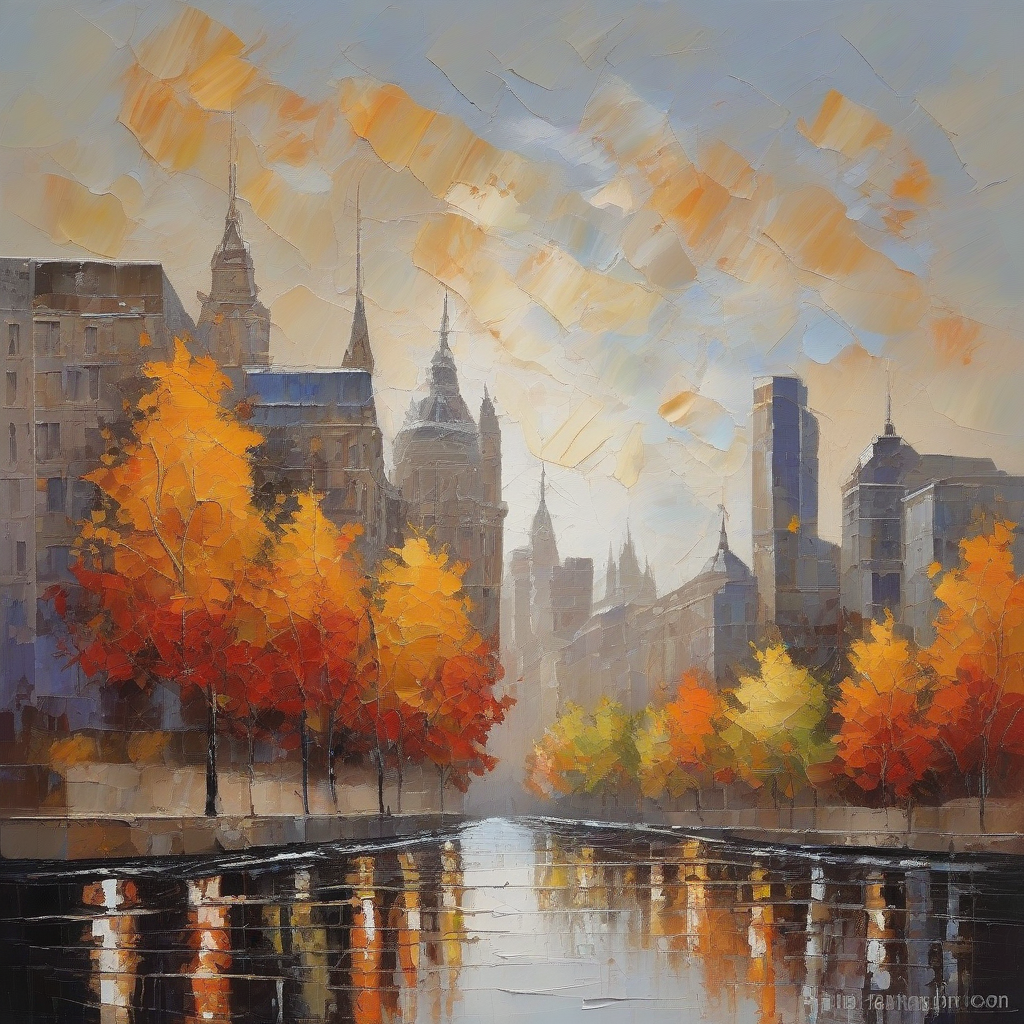

In [ ]:
image1

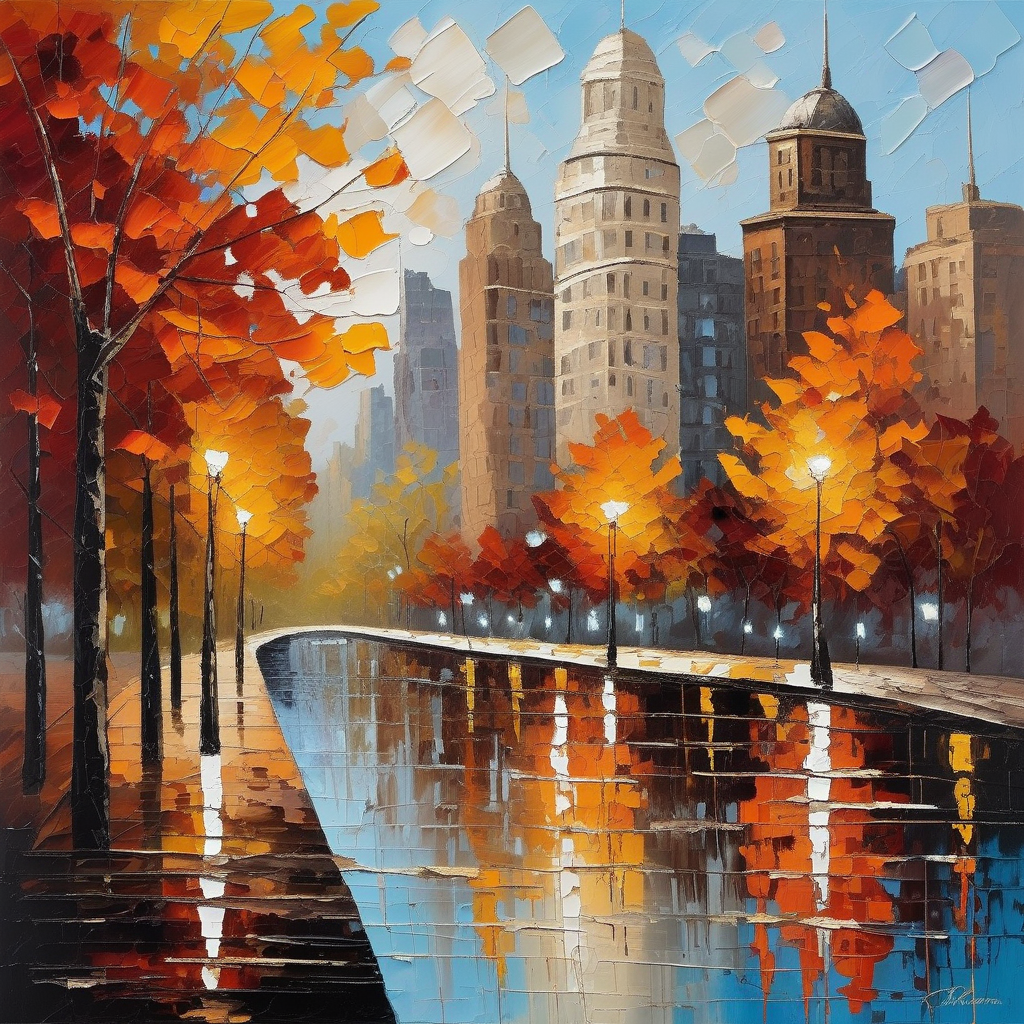

In [ ]:
image2

  0%|          | 0/35 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

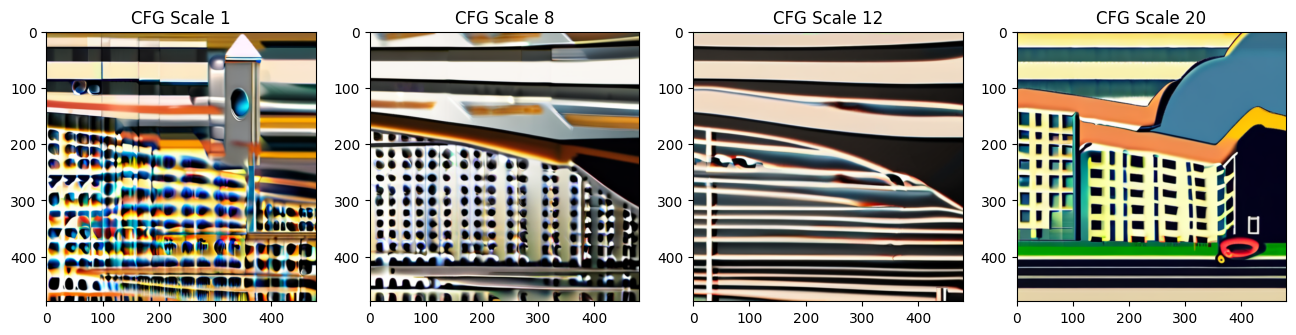

In [ ]:
cfg_scales = [1, 8, 12,20]
prompt = "A sad guy eating burger on the road."
negative_prompt = "low quality, bad quality, oversaturated, blurry"
fig, axs = plt.subplots(1, len(cfg_scales), figsize=(16, 5))
for i, ax in enumerate(axs):
  im = pipe(prompt, negative_prompt, height=480, width=480,
    guidance_scale=cfg_scales[i], num_inference_steps=35,
    generator=torch.Generator(device=device).manual_seed(42)).images[0]
  ax.imshow(im); ax.set_title(f'CFG Scale {cfg_scales[i]}');

# SD-xl base+refiner pipeline  

In [27]:
base = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True)

refiner = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    text_encoder_2=base.text_encoder_2,
    vae=base.vae,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

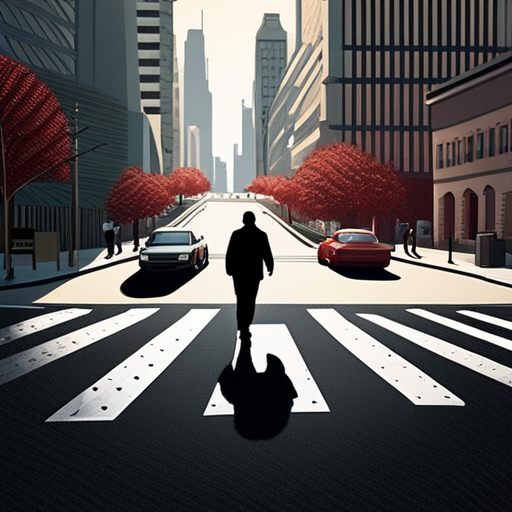

In [28]:
n_steps = 40
high_noise_frac = 0.8

prompt = "A photorealistic image of a man walking across a busy city intersection at a red light, full body visible, wearing casual clothes, natural posture, realistic skin and facial features, detailed clothing texture. Cars stopped behind him. Urban street scene with traffic lights, road markings, and tall buildings. Natural daylight, realistic shadows, high-resolution, crisp details, cinematic photography style."
negative_prompt = "cartoon, 3d render, illustration, blurry, lowres, bad anatomy, extra limbs, distorted face, simplified textures, toy-like, unnatural lighting, cropped, watermark, text"
base.to(device)

image_latent = base(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
    height=512,
    width=512,
    guidance_scale=10
).images

del base
torch.cuda.empty_cache()

refiner.to(device)
image_final = refiner(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image_latent,
).images[0]

del refiner
torch.cuda.empty_cache()

image_final

In [29]:
import gc
del image_latent, image_final
gc.collect()
torch.cuda.empty_cache()